<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2025-08-25 20:36:17--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-results-public.sqlite’

survey-results-publ 100%[===================>] 201.62M  57.0MB/s    in 3.5s    

2025-08-25 20:36:23 (57.1 MB/s) - ‘survey-results-public.sqlite’ saved [211415040/211415040]



#### 2. Connect to the Database


**Install the needed libraries**


In [2]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 135.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 162.0 MB/s eta 0:00:00


In [3]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 73.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 112.3 MB/s eta 0:00:00


In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [5]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


#### Demo 2: List All Tables


In [6]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [7]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


In [8]:
QUERY = """
SELECT distinct *
FROM main 

"""
df = pd.read_sql_query(QUERY, conn)
print(df)


       ResponseId                      MainBranch                 Age  \
0               1  I am a developer by profession  Under 18 years old   
1               2  I am a developer by profession     35-44 years old   
2               3  I am a developer by profession     45-54 years old   
3               4           I am learning to code     18-24 years old   
4               5  I am a developer by profession     18-24 years old   
...           ...                             ...                 ...   
65432       65433  I am a developer by profession     18-24 years old   
65433       65434  I am a developer by profession     25-34 years old   
65434       65435  I am a developer by profession     25-34 years old   
65435       65436  I am a developer by profession     18-24 years old   
65436       65437     I code primarily as a hobby     18-24 years old   

                Employment                            RemoteWork   Check  \
0      Employed, full-time                     

## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


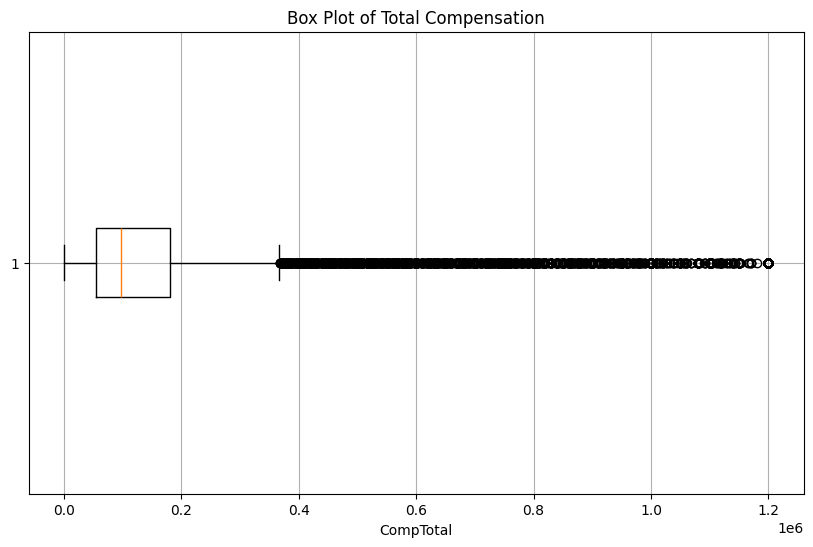

In [9]:
# your code goes here
df = df.dropna(subset=['CompTotal'])

# Optional: Filter out extreme outliers (e.g., above 90th percentile)
upper_limit = df['CompTotal'].quantile(0.90)
df_filtered = df[df['CompTotal'] <= upper_limit]

# Plot box plot
plt.figure(figsize=(10, 6))
plt.boxplot(df_filtered['CompTotal'], vert=False)
plt.title('Box Plot of Total Compensation')
plt.xlabel('CompTotal')
plt.grid(True)
plt.show()

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


/tmp/ipykernel_300/1339172834.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['AgeNumeric'] = df['Age'].map(age_map)


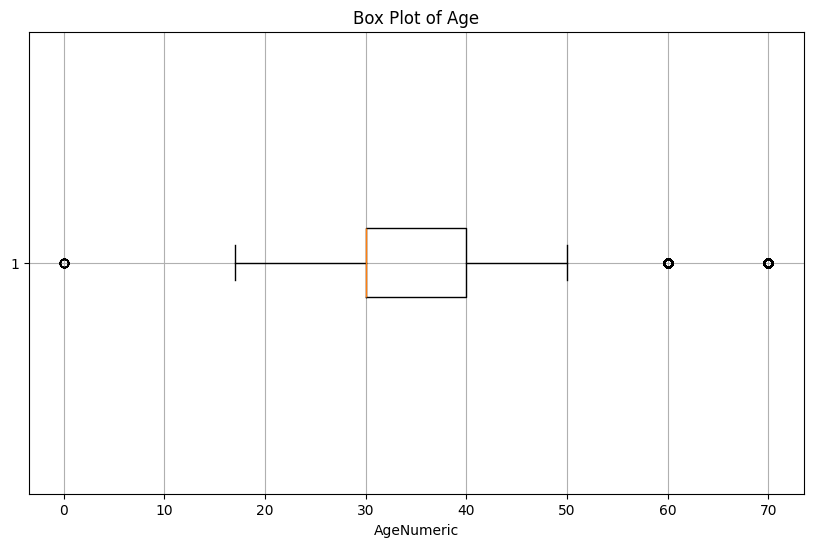

In [10]:
# your code goes here
# Map Age to numeric (example: if Age is categorical like '25-34', '35-44', etc.)
age_map = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70,
    'Prefer not to say': 0
}
df['AgeNumeric'] = df['Age'].map(age_map)

# Drop rows with missing values
df = df.dropna(subset=['AgeNumeric'])

# Plot box plot
plt.figure(figsize=(10, 6))
plt.boxplot(df['AgeNumeric'], vert=False)
plt.title('Box Plot of Age')
plt.xlabel('AgeNumeric')
plt.grid(True)
plt.show()


### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


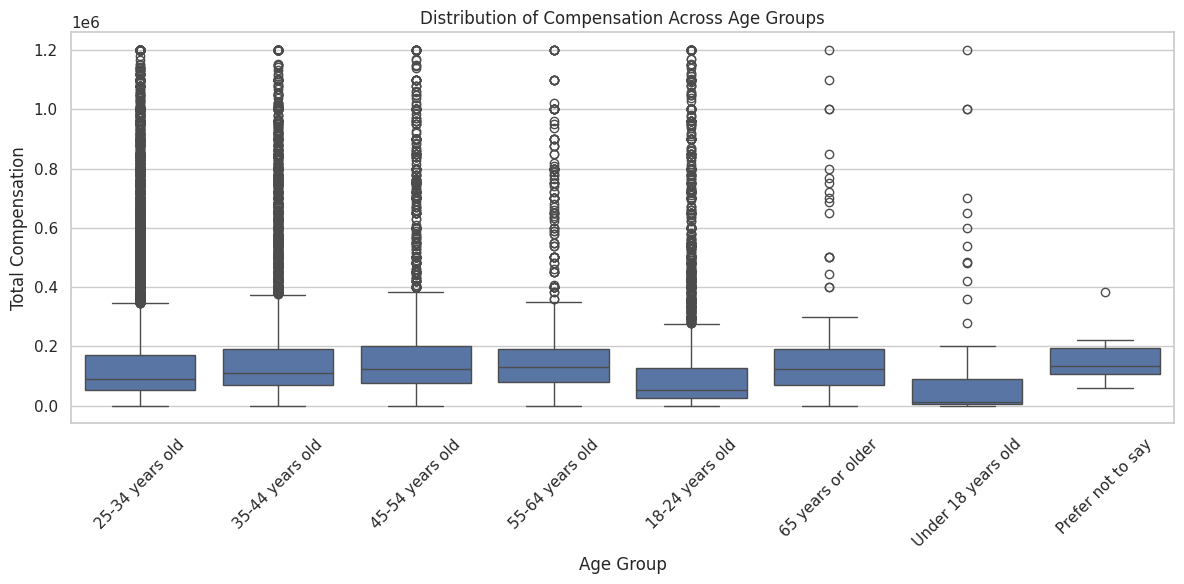

In [14]:
# your code goes here
!pip install seaborn
import seaborn as sns


#Set the plot style
sns.set(style="whitegrid")

# Filter out extreme outliers (e.g., above 90th percentile)
upper_limit = df['CompTotal'].quantile(0.90)
df_filtered = df[df['CompTotal'] <= upper_limit]

# Create the box plot
plt.figure(figsize=(12, 6))
sns.boxplot(x='Age', y='CompTotal', data=df_filtered)

# Customize the plot
plt.xticks(rotation=45)
plt.title('Distribution of Compensation Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Total Compensation')

# Display the plot
plt.tight_layout()
plt.show()


In [17]:
df['JobSatPoints_6'].unique()

array([ 65. ,   nan,   0. ,  20. ,  30. ,  25. ,  50. ,  10. ,   5. ,
        15. ,  18. ,  40. ,  35. ,  33. ,  80. , 100. ,   2. ,  90. ,
        45. ,  34. ,  16. ,  70. ,   7. ,  85. ,  60. ,   1. ,   9. ,
        14. ,  31. ,  12. ,  11. ,  23. ,  28. ,  75. ,   8. ,  81. ,
         6. ,  13. ,  55. ,   3. ,  22. ,  42. ,   4. ,  89. ,  99. ,
        12.5,  36. ,  27. ,  17. ,  95. ,  21. ,  24. ,  19. ,  87. ,
        88. ,  29. ,  33.3,  37. ,  39. ,  77. ,  68. ,  26. ,  32. ,
        66. ,  82. ,  94. ,  78. ,  61. ,  43. ,  69. ,  73. ,  17.5,
        46. ,  49. ,  52. ,  97. ,  96. ,  67. ,  91. ,  86. ,  56. ,
        98. ,  41. ,  74. ,  51. ,  76. ,  48. ,  44. ,  64. ,  54. ,
        63. ])

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


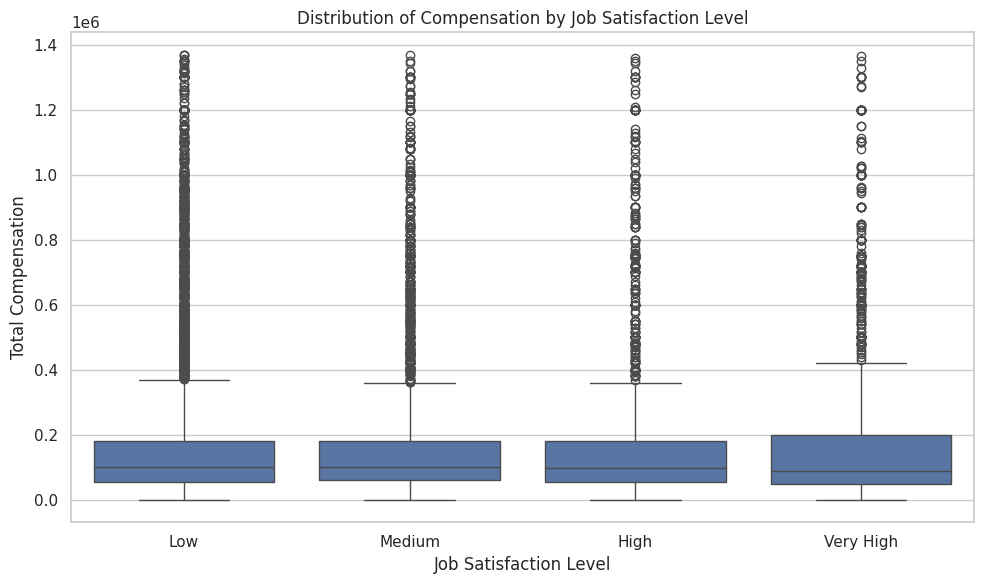

In [38]:
# your code goes here

#Drop NaN values
df = df.dropna(subset=['JobSatPoints_6'])

# Map satisfaction scores to categories
def map_satisfaction(score):
    if score < 25:
        return 'Low'
    elif score < 50:
        return 'Medium'
    elif score < 75:
        return 'High'
    else:
        return 'Very High'

df['SatisfactionLevel'] = df['JobSatPoints_6'].apply(map_satisfaction)

# Filter out extreme outliers (e.g., above 90th percentile)
upper_limit = df['CompTotal'].quantile(0.90)
df_filtered = df[df['CompTotal'] <= upper_limit]


# Plot
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.boxplot(x='SatisfactionLevel', y='CompTotal', data=df_filtered, order=['Low', 'Medium', 'High', 'Very High'])
plt.title('Distribution of Compensation by Job Satisfaction Level')
plt.xlabel('Job Satisfaction Level')
plt.ylabel('Total Compensation')
plt.tight_layout()
plt.show()


### Task 3: Visualizing the Composition of Data


In [23]:
df['DevType'].unique()

array(['Data scientist or machine learning specialist', 'Student',
       'Engineering manager', 'Developer, full-stack',
       'Developer, back-end', 'Academic researcher',
       'Developer, front-end',
       'Developer, embedded applications or devices',
       'Engineer, site reliability', 'Other (please specify):',
       'Developer, mobile', 'Developer, game or graphics',
       'Senior Executive (C-Suite, VP, etc.)', None,
       'Developer, QA or test', 'Data or business analyst',
       'System administrator', 'Cloud infrastructure engineer',
       'Developer, desktop or enterprise applications',
       'Research & Development role', 'Developer Experience',
       'Blockchain', 'Developer, AI', 'Project manager',
       'DevOps specialist', 'Educator', 'Scientist',
       'Security professional', 'Data engineer', 'Designer',
       'Developer Advocate', 'Product manager', 'Database administrator',
       'Hardware Engineer', 'Marketing or sales professional'],
      dtype=o

**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


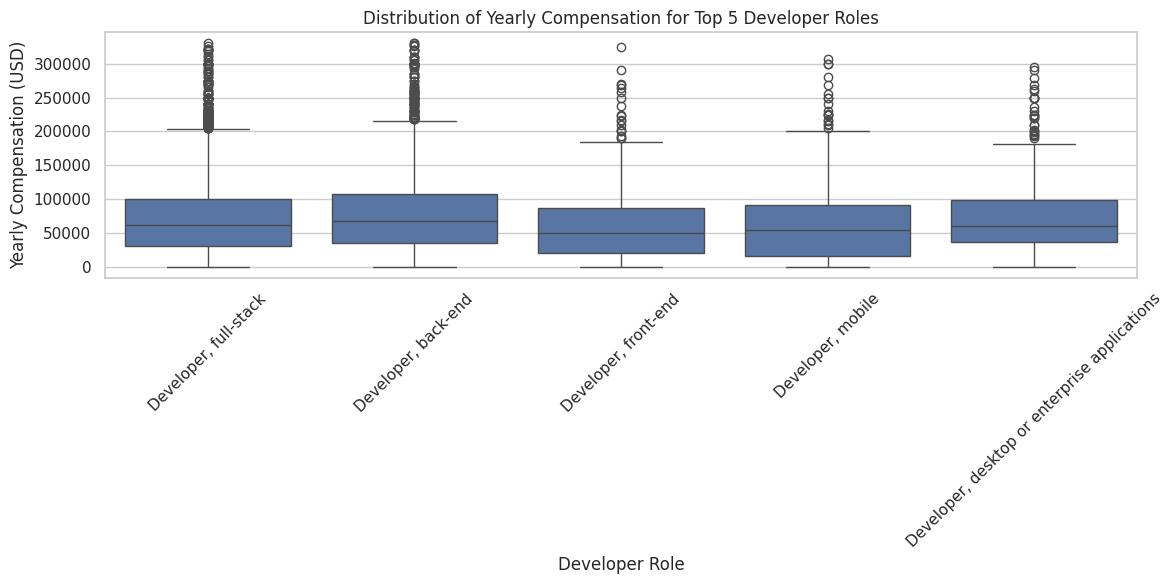

In [26]:
# your code goes here
#Filter top 5 most frequent developer roles
top5_roles = df['DevType'].value_counts().nlargest(5).index.tolist()
df_top5 = df[df['DevType'].isin(top5_roles)]

# Filter out extreme outliers (e.g., above 90th percentile)
upper_limit = df_top5['ConvertedCompYearly'].quantile(0.99)
df_filtered = df_top5[df_top5['ConvertedCompYearly'] <= upper_limit]


# Plot
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.boxplot(x='DevType', y='ConvertedCompYearly', data=df_filtered)
plt.xticks(rotation=45)
plt.title('Distribution of Yearly Compensation for Top 5 Developer Roles')
plt.xlabel('Developer Role')
plt.ylabel('Yearly Compensation (USD)')
plt.tight_layout()
plt.show()


**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


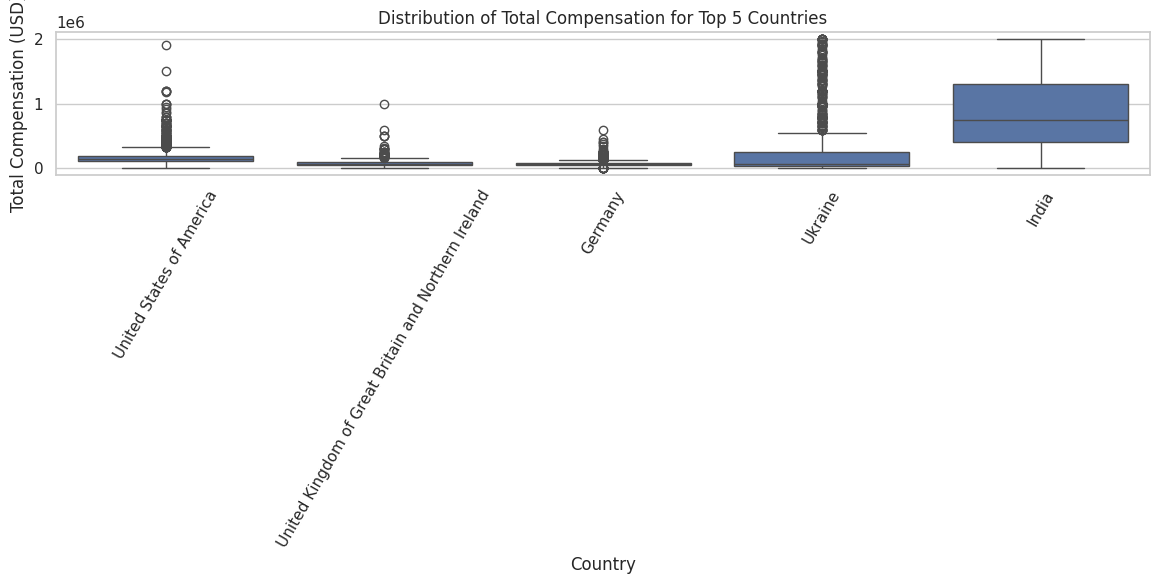

In [31]:
# your code goes here
#Filter respondents from top 5 countries
top5_roles = df['Country'].value_counts().nlargest(5).index.tolist()
df_top5 = df[df['Country'].isin(top5_roles)]

# Filter out extreme outliers (e.g., above 90th percentile)
upper_limit = df_top5['CompTotal'].quantile(0.95)
df_filtered = df_top5[df_top5['CompTotal'] <= upper_limit]


# Plot
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.boxplot(x='Country', y='CompTotal', data=df_filtered)
plt.xticks(rotation=60)
plt.title('Distribution of Total Compensation for Top 5 Countries')
plt.xlabel('Country')
plt.ylabel('Total Compensation (USD)')
plt.tight_layout()
plt.show()

### Task 4: Visualizing Comparison of Data


In [33]:
df['Employment']

72       Employed, full-time;Student, full-time;Indepen...
379                                    Employed, full-time
389                 Employed, full-time;Student, part-time
392                                    Employed, full-time
398                                    Employed, full-time
                               ...                        
65161                                  Employed, full-time
65163                                  Employed, full-time
65166                                  Employed, full-time
65168                                  Employed, full-time
65178                                  Employed, full-time
Name: Employment, Length: 22478, dtype: object

In [32]:
df['Employment'].unique()

array(['Employed, full-time;Student, full-time;Independent contractor, freelancer, or self-employed;Employed, part-time',
       'Employed, full-time', 'Employed, full-time;Student, part-time',
       'Employed, full-time;Independent contractor, freelancer, or self-employed',
       'Independent contractor, freelancer, or self-employed',
       'Employed, full-time;Student, full-time',
       'Student, part-time;Employed, part-time',
       'Independent contractor, freelancer, or self-employed;Employed, part-time',
       'Not employed, but looking for work', 'Employed, part-time',
       'Student, full-time;Independent contractor, freelancer, or self-employed',
       'Employed, full-time;Independent contractor, freelancer, or self-employed;Student, part-time',
       'Employed, full-time;Independent contractor, freelancer, or self-employed;Employed, part-time',
       'Student, full-time;Employed, part-time',
       'Employed, full-time;Employed, part-time',
       'Independent contr

**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


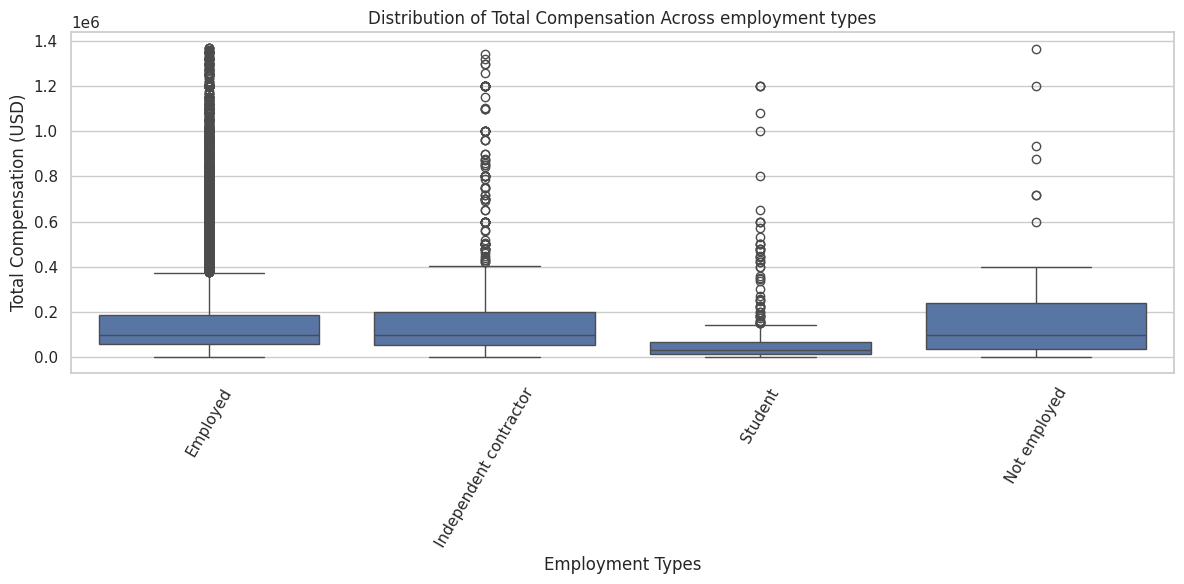

In [36]:
# your code goes here
# drop missing values
df= df.dropna(subset=['Employment', 'CompTotal']) 

# Map to keep only the first item
df['EmploymentMapped'] = df['Employment'].apply(lambda x: x.split(',')[0] if pd.notnull(x) else x)

# Filter out extreme outliers (e.g., above 90th percentile)
upper_limit = df['CompTotal'].quantile(0.90)
df_filtered = df[df['CompTotal'] <= upper_limit]


# Plot
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.boxplot(x='EmploymentMapped', y='CompTotal', data=df_filtered)
plt.xticks(rotation=60)
plt.title('Distribution of Total Compensation Across employment types')
plt.xlabel('Employment Types')
plt.ylabel('Total Compensation (USD)')
plt.tight_layout()
plt.show()

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


In [37]:
df['YearsCodePro'].unique()

array(['1', '6', '7', '18', '30', '16', '17', '4', '15', '11', '23', '10',
       '9', '8', '24', '27', '12', '26', '40', '14', '22', '28', '25',
       '20', 'Less than 1 year', '13', '19', '3', '35', '31', '41', '5',
       '2', None, '32', '38', '21', 'More than 50 years', '36', '34',
       '43', '37', '33', '45', '29', '42', '39', '44', '46', '50', '48',
       '47', '49'], dtype=object)

Examine the distribution of professional coding years by job satisfaction levels.


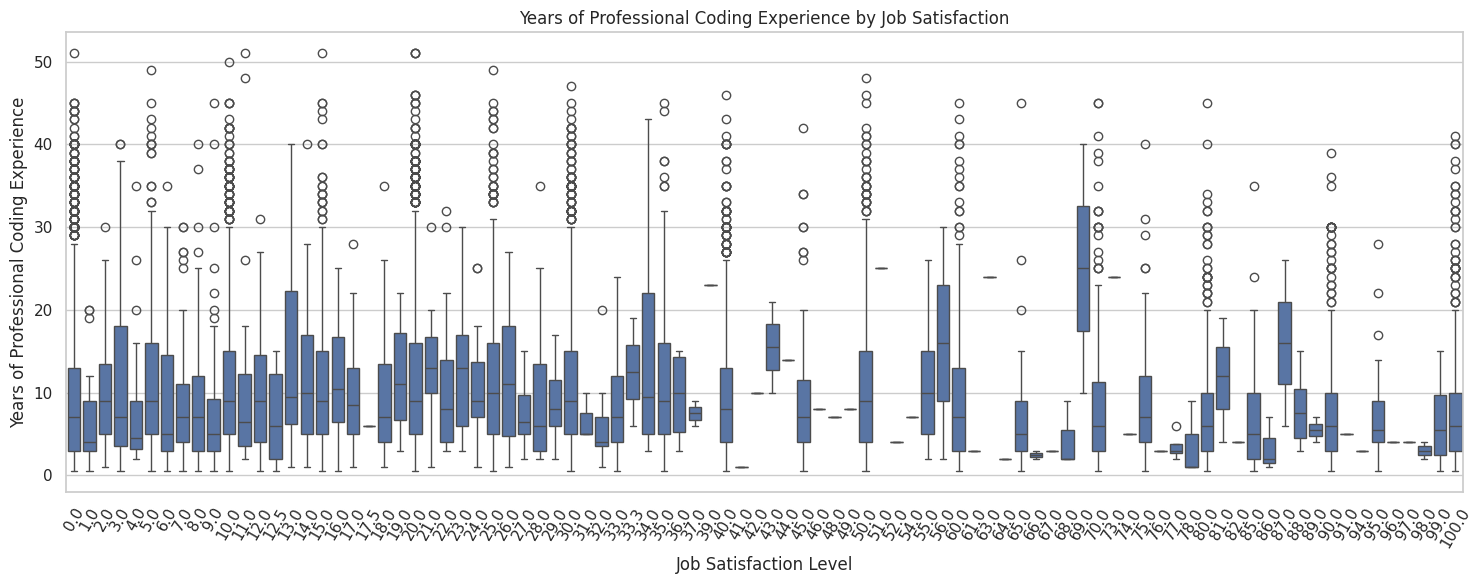

In [46]:
# your code goes here
import numpy as np


# Convert YearsCodePro to numeric
def convert_years_code_pro(value):
    if value == 'Less than 1 year':
        return 0.5
    elif value == 'More than 50 years':
        return 51
    try:
        return float(value)
    except (ValueError, TypeError):
        return np.nan

df['YearsCodeProNumeric'] = df['YearsCodePro'].apply(convert_years_code_pro)

# Drop rows with NaN values
df_clean = df.dropna(subset=['YearsCodeProNumeric', 'JobSatPoints_6'])

# Create box plot
sns.set(style="whitegrid")
plt.figure(figsize=(15, 6))
sns.boxplot(x='JobSatPoints_6', y='YearsCodeProNumeric', data=df_clean)
plt.title('Years of Professional Coding Experience by Job Satisfaction')
plt.xlabel('Job Satisfaction Level')
plt.ylabel('Years of Professional Coding Experience')
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()


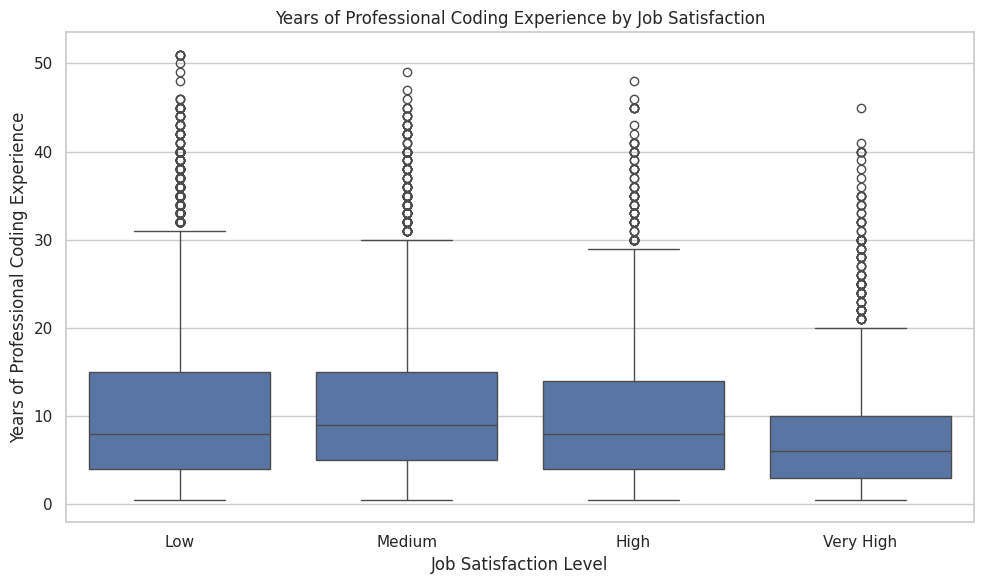

In [43]:
# your code goes here
import numpy as np

# Map satisfaction scores to categories
def map_satisfaction(score):
    if score < 25:
        return 'Low'
    elif score < 50:
        return 'Medium'
    elif score < 75:
        return 'High'
    else:
        return 'Very High'

df['SatisfactionLevel'] = df['JobSatPoints_6'].apply(map_satisfaction)

# Convert YearsCodePro to numeric
def convert_years_code_pro(value):
    if value == 'Less than 1 year':
        return 0.5
    elif value == 'More than 50 years':
        return 51
    try:
        return float(value)
    except (ValueError, TypeError):
        return np.nan

df['YearsCodeProNumeric'] = df['YearsCodePro'].apply(convert_years_code_pro)

# Drop rows with NaN values
df_clean = df.dropna(subset=['YearsCodeProNumeric', 'SatisfactionLevel'])

# Create box plot
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.boxplot(x='SatisfactionLevel', y='YearsCodeProNumeric', data=df_clean, order=['Low', 'Medium', 'High', 'Very High'])
plt.title('Years of Professional Coding Experience by Job Satisfaction')
plt.xlabel('Job Satisfaction Level')
plt.ylabel('Years of Professional Coding Experience')
plt.tight_layout()
plt.show()


### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [47]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
